# Map Converter
From https://github.com/CL2-UWaterloo/Raceline-Optimization/blob/master/map_converter.ipynb: used here to create track centerlines from pngs / pgms

In [1]:
import numpy as np
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import yaml
import scipy
from scipy.ndimage import distance_transform_edt as edt
from PIL import Image
import os

In [ ]:
# Modified from https://github.com/CL2-UWaterloo/Head-to-Head-Autonomous-Racing/blob/main/gym/f110_gym/envs/laser_models.py
# load map image
map_name = f"maps/levine/levine_map"
# if os.path.exists(map_name):
#     if os.path.exists(f"{map_name}.png"):
#         map_img_path = f"{map_name}.png"
#     elif os.path.exists(f"{map_name}.pgm"):
#         map_img_path = f"{map_name}.pgm"
#     else:
#         raise Exception(f"Map image not found")
# else:
#     raise Exception(f"Map directory {map_name} not found")
map_name = os.path.join(os.getcwd(), map_name)
map_yaml_path = f"{map_name}.yaml"
raw_map_img = np.array(Image.open(f'{map_name}.png').transpose(Image.FLIP_TOP_BOTTOM))
raw_map_img = raw_map_img.astype(np.float64)
plt.figure(figsize=(10, 10))
plt.imshow(raw_map_img, cmap='gray', origin='lower')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/bryanalfaro/Documents/Problem_Sets/ese6500_final/f1tenth_gym/maps/levine/levine.png'

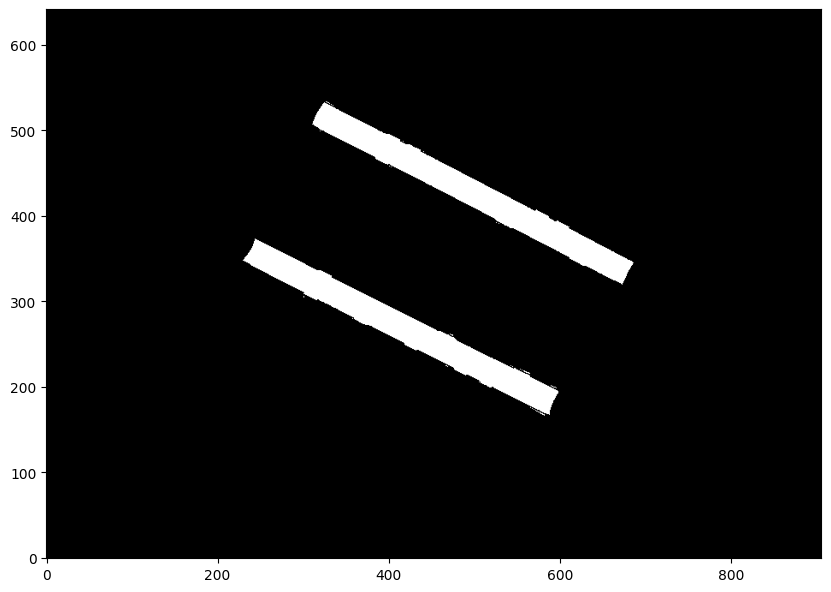

In [9]:
# grayscale -> binary. Converts grey to black
map_img = raw_map_img.copy()
map_img[map_img <= 210.] = 0
map_img[map_img > 210.] = 1

map_height = map_img.shape[0]
# map_width = map_img.shape[1]
map_img
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')

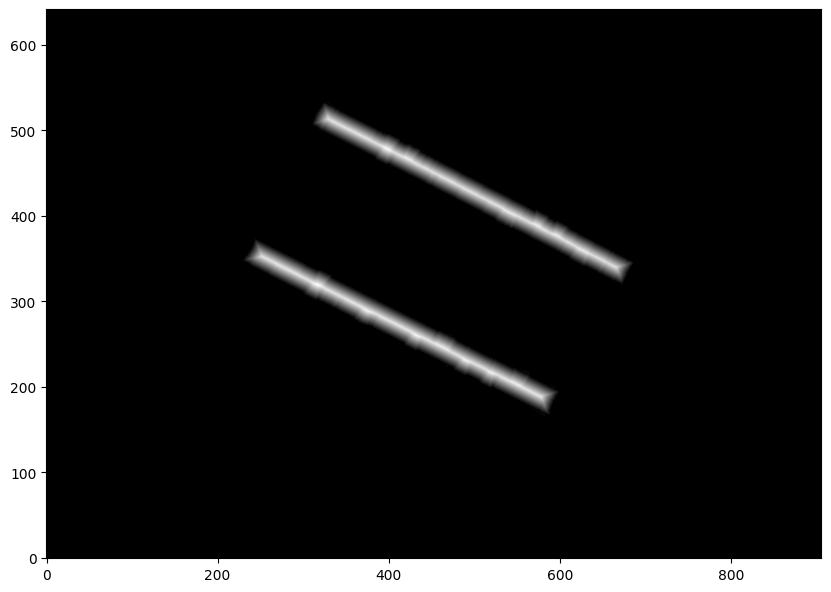

In [ ]:
plt.figure(figsize=(10, 10))
# Calculate Euclidean Distance Transform (tells us distance to nearest wall)
dist_transform = scipy.ndimage.distance_transform_edt(map_img)
plt.imshow(dist_transform, cmap='gray', origin='lower')


(642, 906)


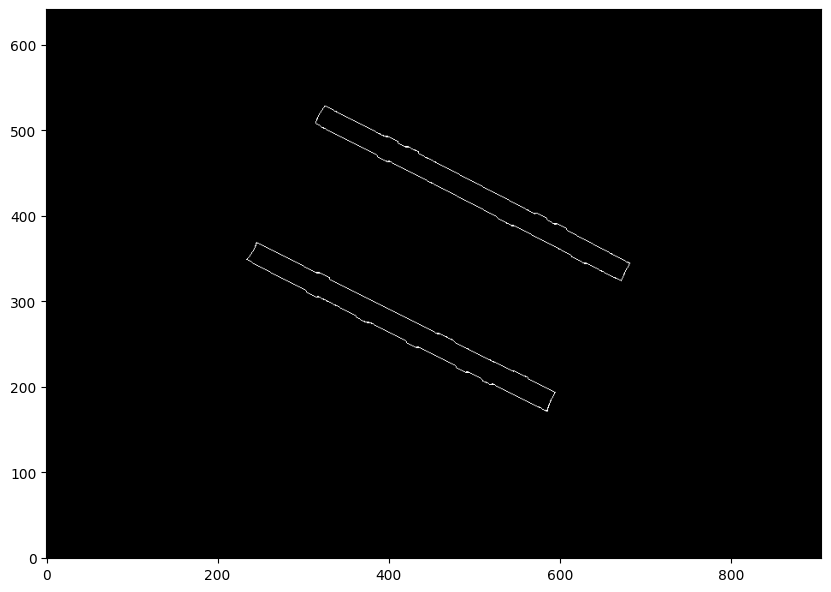

In [16]:

# Threshold the distance transform to create a binary image
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        print(ex)
lo_threshold = 0.15 / map_resolution
hi_threshold = 0.2 / map_resolution
THRESHOLD = 0.1 # You should play around with this number. Is you say hairy lines generated, either clean the map so it is more curvy or increase this number
edges = np.logical_and(lo_threshold <= dist_transform, dist_transform <= hi_threshold)
print(edges.shape)
plt.figure(figsize=(10, 10))
plt.imshow(edges, origin='lower', cmap='gray')
plt.imsave('maps/levine_halls/edges.png', edges, cmap='gray', origin='lower')

### EDIT ON GIMP AT THIS POINT TO ONLY HAVE THE OUTSIDE EDGES OF THE HALLS ###

0 2


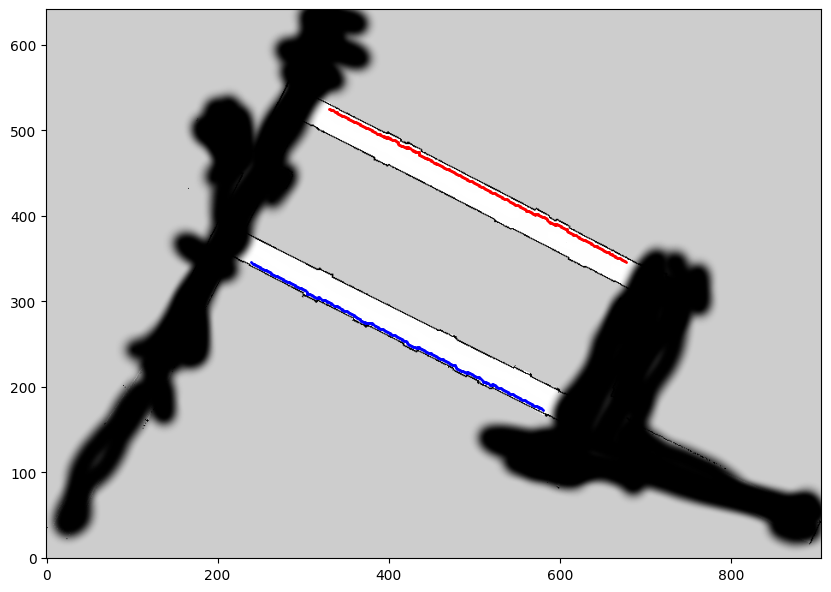

In [44]:
import cv2 as cv
edges = np.array(Image.open(f'maps/levine_halls/edges.png').transpose(Image.FLIP_TOP_BOTTOM))
edges = edges > 230

# use connected components to split into the two walls, use this to get beadings later on
_, labels, _, _ = cv.connectedComponentsWithStats(edges.astype(np.uint8))
print(np.min(labels), np.max(labels)) # should be 0, 2 if everything preceding worked well
## overlay to visualize correctness
edge1 = labels == 1
edge2 = labels == 2
edge1_x, edge1_y = np.nonzero(edge1)
edge2_x, edge2_y = np.nonzero(edge2)
# print(edge_x.shape)
plt.figure(figsize=(10, 10))
plt.imshow(raw_map_img, cmap='gray', origin='lower')
plt.scatter(edge1_y, edge1_x, s=1.0, c='b')
plt.scatter(edge2_y, edge2_x, s=1.0, c='r')

In [52]:
# convert to x y coordinates in map frame
orig_x = origin[0]
orig_y = origin[1]
# ??? Should be 0
orig_s = np.sin(origin[2])
orig_c = np.cos(origin[2])

data1 = np.column_stack((edge1_y, edge1_x)).astype(np.float64)
data1 *= map_resolution
data1 += np.array([[orig_x, orig_y]])
# yaw calculations
# # NOTE: based on plotting results, will need to turn wall 1's yaw by p
yaw = np.diff(data1, axis=0)
yaw = np.mean(yaw, axis=0)
yaw = np.arctan2(yaw[1], yaw[0])
yaw -= np.pi
data1 = np.hstack((data1, yaw * np.ones((len(edge1_x), 1))))

data2 = np.column_stack((edge2_y, edge2_x)).astype(np.float64)
data2 *= map_resolution
data2 += np.array([[orig_x, orig_y]])
yaw = np.diff(data2, axis=0)
yaw = np.mean(yaw, axis=0)
yaw = np.arctan2(yaw[1], yaw[0])
data2 = np.hstack((data2, yaw * np.ones((len(edge2_x), 1))))
print(yaw)


np.savetxt('maps/levine_halls/possible_targets_wall1.csv', data1, delimiter=',')
np.savetxt('maps/levine_halls/possible_targets_wall2.csv', data2, delimiter=',')

2.6641686486830656
